# **Description**

**Introduce**
The Breast Cancer Classification using Clinical and Biopsy Data project focuses on leveraging machine learning models to classify breast tumors as benign or malignant based on clinical biomarkers and biopsy features. The project compares various machine learning algorithms, such as classical models (SVM, Random Forest, Logistic Regression) and deep learning models (MLP), to assess predictive accuracy. The analysis also emphasizes feature importance and interpretable AI methods, such as SHAP, to understand the most relevant factors influencing tumor classification

**Research Question**
1. Can machine learning models reliably classify breast tumors as benign or malignant based on clinical and biopsy data?

2. What clinical and biopsy features are most indicative of tumor malignancy, and how do feature interactions affect the model's robustness?

3. How do model complexity and interpretability (e.g., through SHAP or feature importance) impact the classification of breast cancer in clinical decision support?

**Dataset Details:**

**Name:** Breast Cancer Wisconsin Diagnostic Dataset

**Source:** UCI Machine Learning Repository - Breast Cancer Wisconsin Diagnostic Data Set

**Contributors:** Dr. William H. Wolberg at the University of Wisconsin Hospitals, Madison, USA

# **Section 1: Importing Relevent Files**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np



# **Section 2: Loading Files**
In This section, I loaded the files and corrected the names of Columns

In [ ]:

# Load the dataset
df = pd.read_csv('wdbc.data', header=None)

# specifying column names
column_names = [
    'ID', 'Diagnosis',
    'Radius_mean', 'Texture_mean', 'Perimeter_mean', 'Area_mean', 'Smoothness_mean',
    'Compactness_mean', 'Concavity_mean', 'Concave_points_mean', 'Symmetry_mean',
    'Fractal_dimension_mean', 'Radius_se', 'Texture_se', 'Perimeter_se', 'Area_se',
    'Smoothness_se', 'Compactness_se', 'Concavity_se', 'Concave_points_se', 'Symmetry_se',
    'Fractal_dimension_se', 'Radius_worst', 'Texture_worst', 'Perimeter_worst',
    'Area_worst', 'Smoothness_worst', 'Compactness_worst', 'Concavity_worst',
    'Concave_points_worst', 'Symmetry_worst', 'Fractal_dimension_worst'
]


## **Printing Column Names**

In [ ]:

df.columns = column_names

df.columns

Index(['ID', 'Diagnosis', 'Radius_mean', 'Texture_mean', 'Perimeter_mean',
       'Area_mean', 'Smoothness_mean', 'Compactness_mean', 'Concavity_mean',
       'Concave_points_mean', 'Symmetry_mean', 'Fractal_dimension_mean',
       'Radius_se', 'Texture_se', 'Perimeter_se', 'Area_se', 'Smoothness_se',
       'Compactness_se', 'Concavity_se', 'Concave_points_se', 'Symmetry_se',
       'Fractal_dimension_se', 'Radius_worst', 'Texture_worst',
       'Perimeter_worst', 'Area_worst', 'Smoothness_worst',
       'Compactness_worst', 'Concavity_worst', 'Concave_points_worst',
       'Symmetry_worst', 'Fractal_dimension_worst'],
      dtype='object')

## **Printing First Few Columns**

In [ ]:
# Display first few rows to check
df.head()


,ID,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# **Setion 3: Exploratory Data Analysis**

## **Checking missingness**

In [ ]:
# Check for missing values
df.isnull().sum()


,0
ID,0
Diagnosis,0
Radius_mean,0
Texture_mean,0
Perimeter_mean,0
Area_mean,0
Smoothness_mean,0
Compactness_mean,0
Concavity_mean,0
Concave_points_mean,0


## **Displaying Shape of Dataset**

In [ ]:
df.shape

(569, 32)

## **Descriptive statistical Analysis**

In [ ]:
df.describe()

,ID,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,Symmetry_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## **Count in Target Column**

In [ ]:
# Check the original counts for 'M' (Malignant) and 'B' (Benign)
df['Diagnosis'].value_counts()


,count
Diagnosis,
B,357
M,212


## **Converting Malignant to 1 and Benine to 0**

In [ ]:
# Convert 'M' to 1 and 'B' to 0
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Display the first few rows to confirm the conversion
df.head()

,ID,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## **Distribution of Numerical Features**

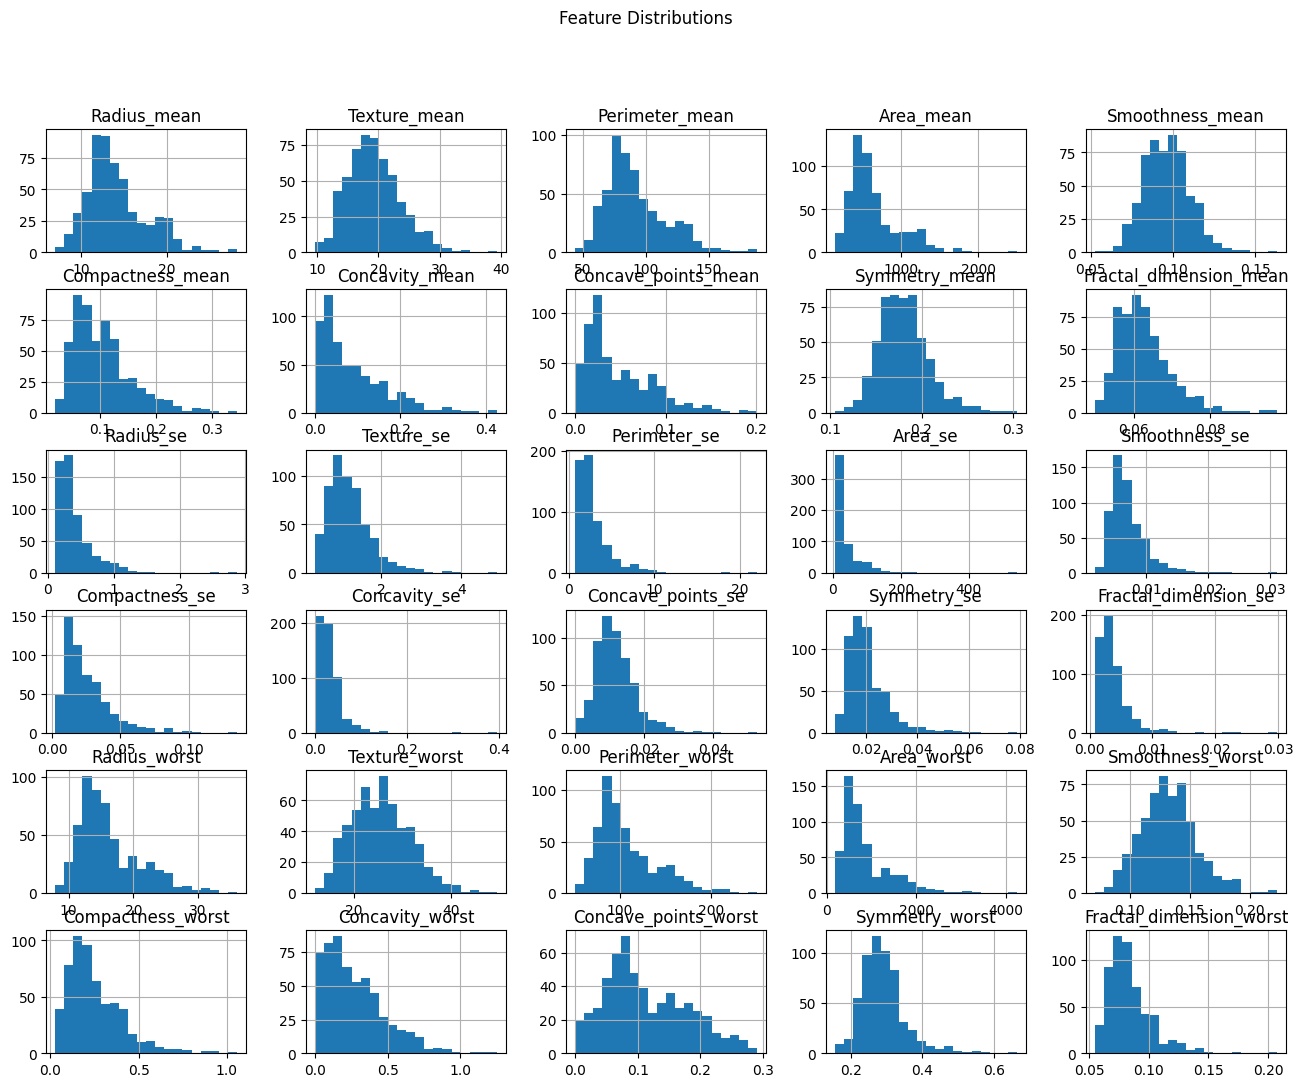

In [ ]:
# Histograms of numerical features
df.iloc[:, 2:].hist(bins=20, figsize=(16, 12))
plt.suptitle('Feature Distributions')
plt.show()


## **Distribution of Target Variable**

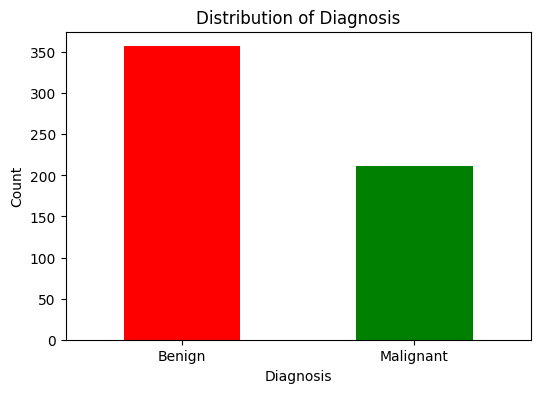

In [ ]:

# Distribution of diagnosis (Malignant vs Benign)
plt.figure(figsize=(6, 4))
df['Diagnosis'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribution of Diagnosis')
plt.xticks([0, 1], ['Benign', 'Malignant'], rotation=0)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


## **Box Plot**

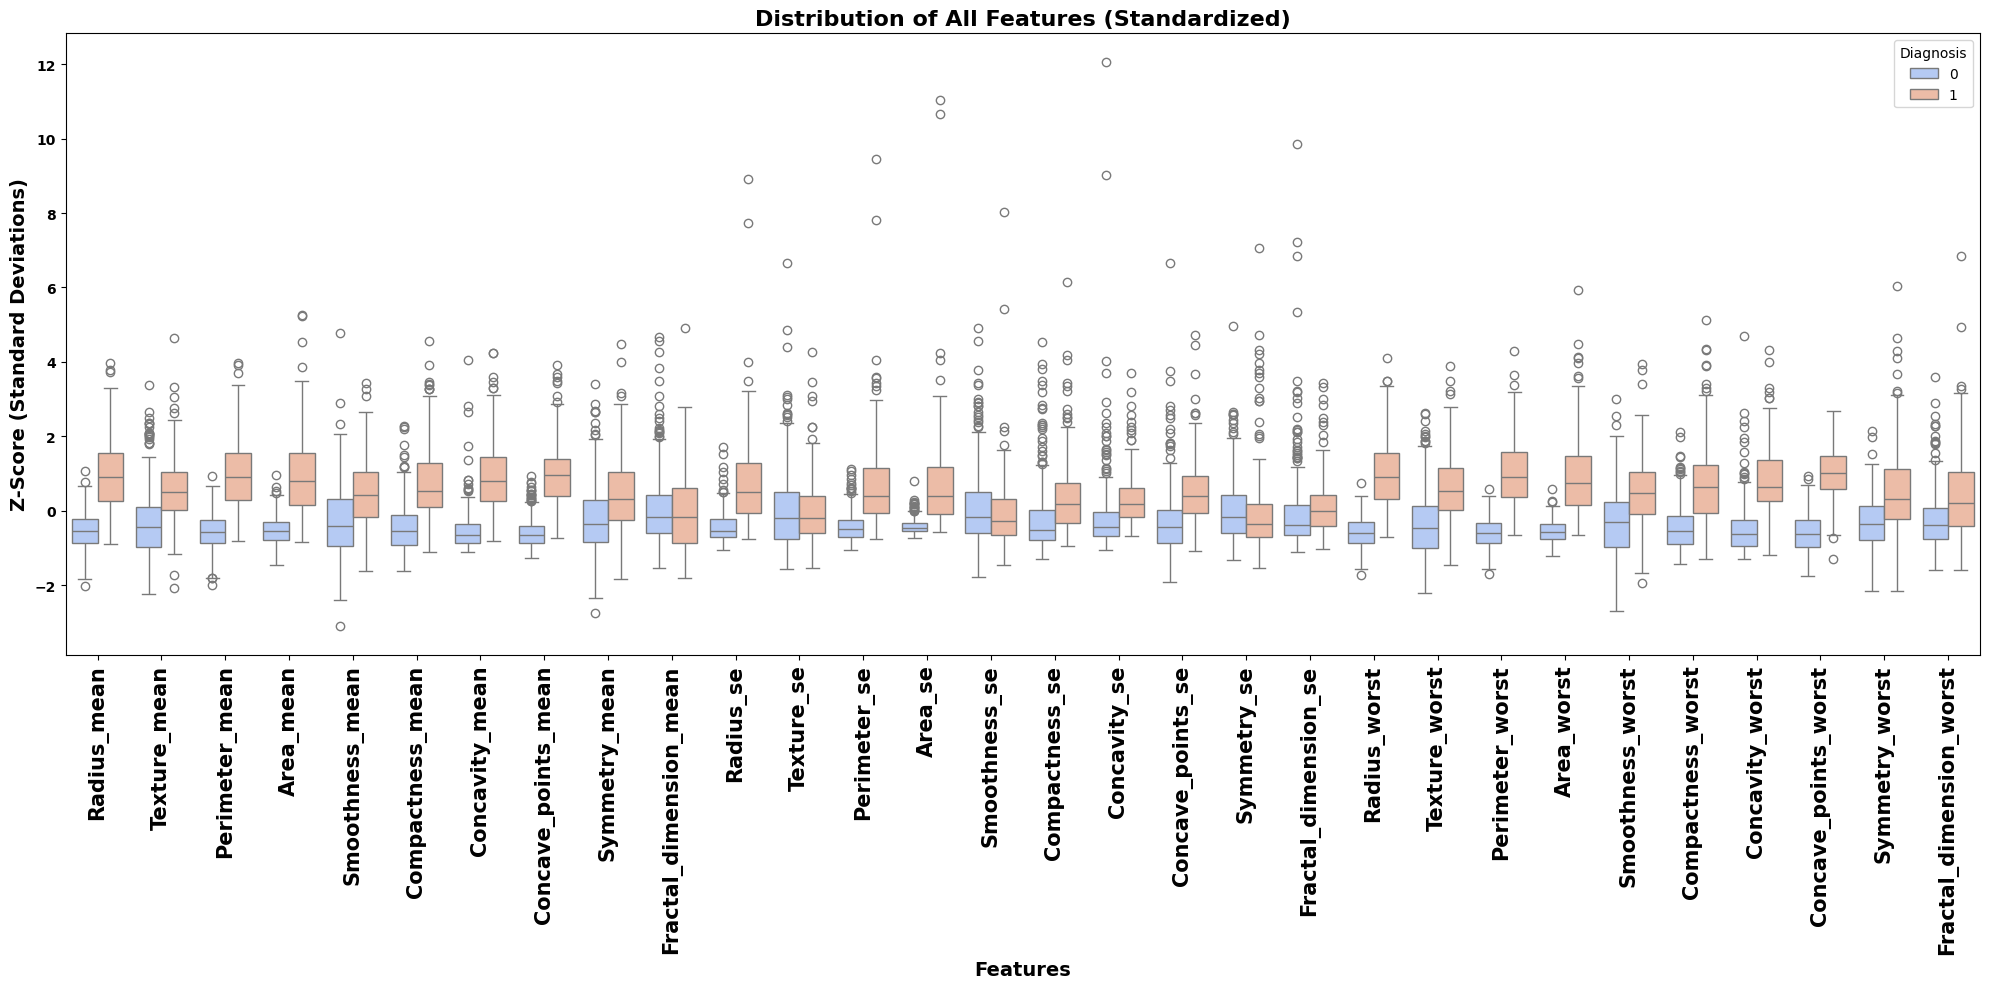

In [ ]:

plt.figure(figsize=(20, 10))
sns.boxplot(
    x="Feature",
    y="Standardized Value",
    hue="Diagnosis",
    data=df_melted,
    palette="coolwarm"
)

# Bold the X-ticks (Feature names)
plt.xticks(rotation=90, fontweight='bold',fontsize=15)

# Bold the Y-ticks (Z-score numbers)
plt.yticks(fontweight='bold')

# Bold the Labels
plt.xlabel("Features", fontweight='bold', fontsize=14)
plt.ylabel("Z-Score (Standard Deviations)", fontweight='bold', fontsize=14)

plt.title("Distribution of All Features (Standardized)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## **Correlation metrics of Top numerical features**

Top 10 Features correlated with Diagnosis:
['Concave_points_worst', 'Perimeter_worst', 'Concave_points_mean', 'Radius_worst', 'Perimeter_mean', 'Area_worst', 'Radius_mean', 'Area_mean', 'Concavity_mean', 'Concavity_worst']


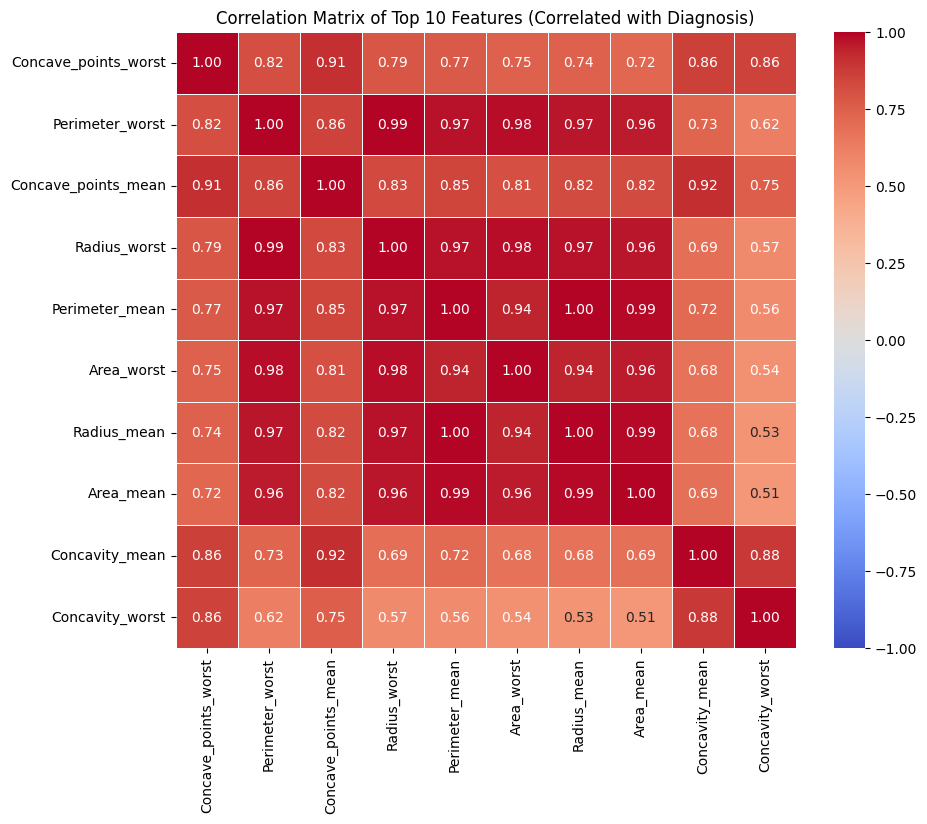

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlations of all features with the Target ('Diagnosis')
# Drop the ID column if it exists, as it's not a predictive feature
X_corr = df.iloc[:, 1:].copy() # Includes Diagnosis and all features, excludes ID
correlations = X_corr.corr()['Diagnosis'].abs().sort_values(ascending=False)

# 2. Select the Top 10 features (excluding Diagnosis itself)
# We take [1:11] because index 0 is 'Diagnosis' itself (correlation 1.0)
top_10_features = correlations[1:11].index.tolist()

print("Top 10 Features correlated with Diagnosis:")
print(top_10_features)

# 3. Create a subset DataFrame with only these top 10 features
df_top10 = df[top_10_features]

# 4. Calculate the correlation matrix for these specific features
corr_matrix_top10 = df_top10.corr()

# 5. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_top10,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Matrix of Top 10 Features (Correlated with Diagnosis)')
plt.show()

# **Section 4: Dataset Splitting & Model Training**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    brier_score_loss, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibrationDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42

X = df.drop(columns=['Diagnosis', 'ID']) if 'ID' in df.columns else df.drop(columns=['Diagnosis'])
y = df['Diagnosis'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

def eval_binary(y_true, y_prob, threshold=0.5):
    """Return dict: ROC-AUC, Acc, Prec, Recall, F1, Specificity, Brier."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "specificity": specificity,
        "brier": brier_score_loss(y_true, y_prob)
    }

def fit_time_predict(estimator, X_tr, y_tr, X_te):
    """Fit -> training time; predict prob -> testing time. Returns (fitted, train_s, y_prob, test_s)."""
    t0 = perf_counter()
    estimator.fit(X_tr, y_tr)
    train_s = perf_counter() - t0

    t1 = perf_counter()
    if hasattr(estimator, "predict_proba"):
        y_prob = estimator.predict_proba(X_te)[:, 1]
    else:
        # Convert decision_function to [0,1] if no predict_proba
        scores = estimator.decision_function(X_te)
        smin, smax = scores.min(), scores.max()
        y_prob = (scores - smin) / (smax - smin + 1e-12)
    test_s = perf_counter() - t1
    return estimator, train_s, y_prob, test_s

## **RQ1 — To what extent can a combination of clinical biomarkers and biopsy features reliably classify breast tumors as benign or malignant, and how does feature interaction affect model robustness?**


**Multi-model performance on a held-out test set (metrics + training/testing time)**

In [ ]:
models = {
    "LogReg": make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=5000, solver="lbfgs", random_state=RANDOM_STATE)),
    "SVM_RBF": make_pipeline(StandardScaler(),
                             SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),

}


results, times, probs_test, fitted = [], {}, {}, {}

for name, est in models.items():
    mdl, tr_s, y_prob, te_s = fit_time_predict(est, X_train, y_train, X_test)
    results.append({"model": name, **eval_binary(y_test, y_prob, threshold=0.5)})
    times[name] = {"train_s": tr_s, "test_s": te_s}
    probs_test[name] = y_prob
    fitted[name] = mdl

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
times_df = pd.DataFrame(times).T.reset_index().rename(columns={"index":"model"})

print("=== RQ1 — Test Metrics (sorted by ROC-AUC) ===")
display(results_df)
print("\n=== Train/Test Time (seconds) ===")
display(times_df)


=== RQ1 — Test Metrics (sorted by ROC-AUC) ===


,model,roc_auc,accuracy,precision,recall,f1,specificity,brier
0,LogReg,0.996032,0.964912,0.975000,0.928571,0.951220,0.986111,0.021313
1,SVM_RBF,0.994709,0.964912,0.952381,0.952381,0.952381,0.972222,0.022222
2,RandomForest,0.992890,0.973684,1.000000,0.928571,0.962963,1.000000,0.032415



=== Train/Test Time (seconds) ===


,model,train_s,test_s
0,LogReg,0.029488,0.002675
1,SVM_RBF,0.036203,0.004525
2,RandomForest,0.304164,0.049428


## **Robustness via cross-validated (5-fold) performance across models**

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc_rows = []
for name, est in models.items():
    aucs = cross_val_score(est, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_auc_rows.append({"model": name, "auc_mean": aucs.mean(), "auc_std": aucs.std()})

cv_auc_df = pd.DataFrame(cv_auc_rows).sort_values("auc_mean", ascending=False).reset_index(drop=True)
print("=== RQ1 — 5-fold CV ROC-AUC ===")
display(cv_auc_df)


=== RQ1 — 5-fold CV ROC-AUC ===


,model,auc_mean,auc_std
0,LogReg,0.995314,0.005345
1,SVM_RBF,0.994525,0.005980
2,RandomForest,0.988548,0.008269


# **Section 5: Hyperparameter optimization of the models using GridSearch**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, brier_score_loss
)


pipelines = {
    "LogReg": make_pipeline(
        StandardScaler(),
        LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
    ),
    "SVM_RBF": make_pipeline(
        StandardScaler(),
        SVC(probability=True, random_state=42)
    ),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1)
}


param_grids = {
    "LogReg": {
        'logisticregression__C': [0.01, 0.1, 1, 10],
        'logisticregression__class_weight': [None, 'balanced']
    },
    "SVM_RBF": {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto']
    },
    "RandomForest": {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
}

grid_results = []
best_models = {}
cv_results = []

print("=== PHASE 1: Hyperparameter Tuning & Multi-Metric Evaluation ===")

for name, pipeline in pipelines.items():
    print(f"Optimizing {name}...")


    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Predictions for the Test Set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Collect detailed metrics
    grid_results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Brier Score": brier_score_loss(y_test, y_proba),
        "Best Params": grid.best_params_ # Full dictionary of params
    })

print("\n=== PHASE 2: Stability Check (Cross-Validation) ===")

# Metrics to track during Cross-Validation
scoring_metrics = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

for name, model in best_models.items():
    # Use cross_validate to get multiple metrics at once
    cv_out = cross_validate(
        model, X_train, y_train,
        cv=5,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": np.mean(cv_out['test_roc_auc']),
        "CV ROC-AUC Std": np.std(cv_out['test_roc_auc']),
        "Mean CV Accuracy": np.mean(cv_out['test_accuracy']),
        "Mean CV F1": np.mean(cv_out['test_f1'])
    })


# Set pandas options to show full content in columns (essential for "Best Params")
pd.set_option('display.max_colwidth', None)

grid_df = pd.DataFrame(grid_results).sort_values(by="ROC-AUC", ascending=False)
cv_df = pd.DataFrame(cv_results).sort_values(by="Mean CV ROC-AUC", ascending=False)

print("\n--- 1. Comprehensive Test Set Performance ---")
display(grid_df)

print("\n--- 2. Model Stability (Mean CV Scores) ---")
display(cv_df)

=== PHASE 1: Hyperparameter Tuning & Multi-Metric Evaluation ===
Optimizing LogReg...
Optimizing SVM_RBF...
Optimizing RandomForest...

=== PHASE 2: Stability Check (Cross-Validation) ===

--- 1. Comprehensive Test Set Performance ---


,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score,Brier Score,Best Params
2,RandomForest,0.995040,0.973684,1.00000,0.928571,0.962963,0.032081,"{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}"
1,SVM_RBF,0.992725,0.973684,1.00000,0.928571,0.962963,0.023768,"{'svc__C': 10, 'svc__gamma': 'scale'}"
0,LogReg,0.986442,0.973684,0.97561,0.952381,0.963855,0.028490,"{'logisticregression__C': 10, 'logisticregression__class_weight': None}"



--- 2. Model Stability (Mean CV Scores) ---


,Model,Mean CV ROC-AUC,CV ROC-AUC Std,Mean CV Accuracy,Mean CV F1
0,LogReg,0.995769,0.004812,0.971429,0.961063
1,SVM_RBF,0.994427,0.006039,0.973626,0.964742
2,RandomForest,0.990557,0.011035,0.958242,0.943664


**Do explicit feature interactions help? (interaction-only LR vs base LR**

In [ ]:

# Assuming you want a standard RF, or use models["RandomForest"] if you defined it earlier
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

rf_interact = Pipeline([
    ("scaler", StandardScaler()), # Optional for RF, but keeps pipeline robust
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

# Calculate CV scores
aucs_base = cross_val_score(rf_base, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
aucs_int  = cross_val_score(rf_interact, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)

# Create comparison DataFrame
interaction_cmp = pd.DataFrame({
    "model": ["RF_base", "RF_interactions"],
    "auc_mean": [aucs_base.mean(), aucs_int.mean()],
    "auc_std":  [aucs_base.std(),  aucs_int.std()]
}).sort_values("auc_mean", ascending=False).reset_index(drop=True)

print("=== RQ1 — Effect of explicit pairwise interactions on RF (5-fold CV ROC-AUC) ===")
display(interaction_cmp)

=== RQ1 — Effect of explicit pairwise interactions on RF (5-fold CV ROC-AUC) ===


,model,auc_mean,auc_std
0,RF_interactions,0.989725,0.007893
1,RF_base,0.988548,0.008269


# **ROC curves and confusion Matrices(test set; all models)**

**ROC Curves**

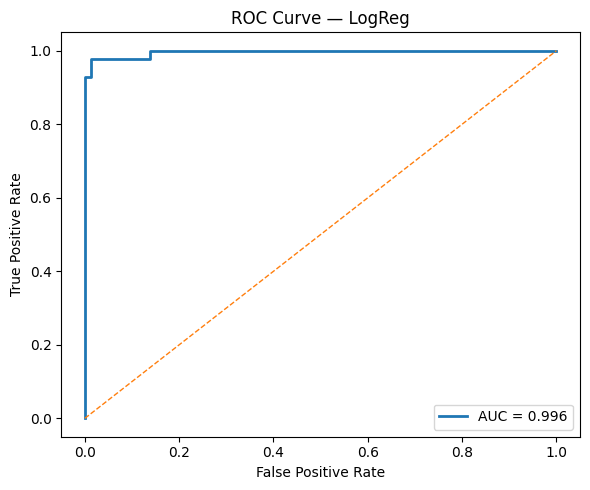

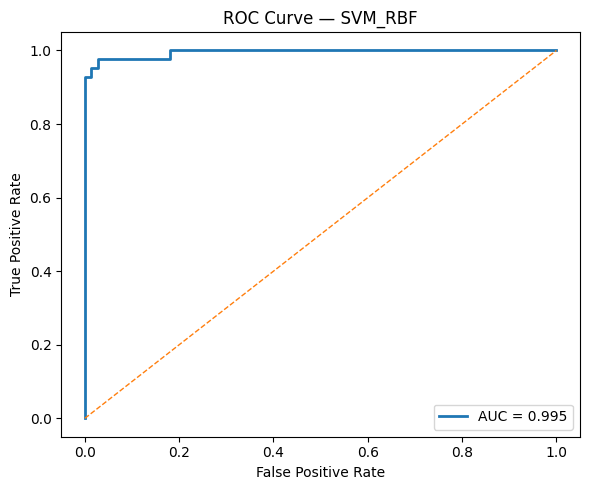

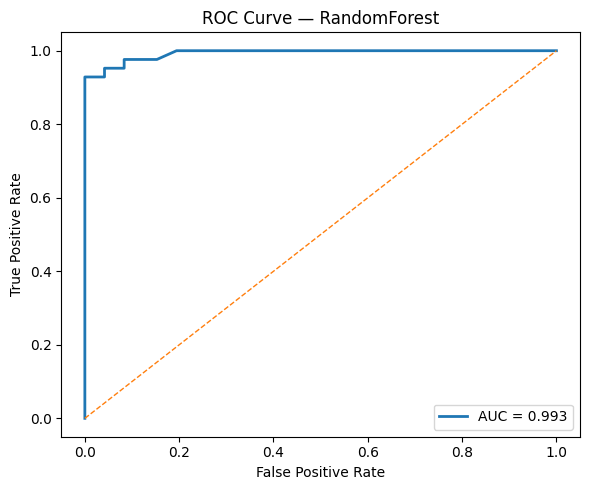

In [ ]:

import os
from sklearn.metrics import roc_curve, roc_auc_score

SAVE_FIGS = False  # set True to save PNGs
OUTDIR = "figs_roc_confusion"
os.makedirs(OUTDIR, exist_ok=True)

for name, y_prob in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
    plt.plot([0,1], [0,1], "--", linewidth=1)
    plt.title(f"ROC Curve — {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(os.path.join(OUTDIR, f"ROC_{name}.png"), dpi=200)
    plt.show()


**Confusion Matrices**

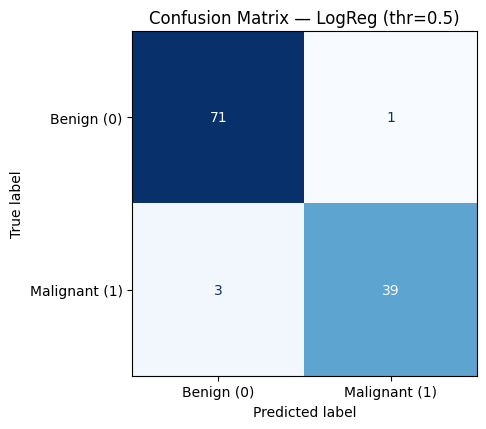

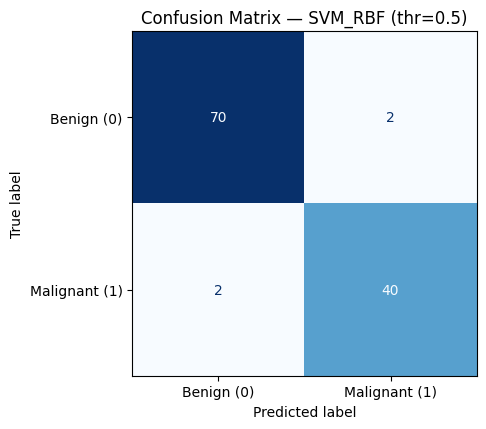

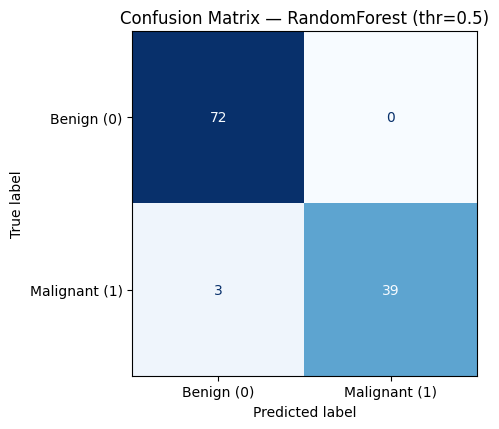

In [ ]:
# 5) Confusion matrices — one figure per model (threshold = 0.5)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SAVE_FIGS = False  # set True to save PNGs
OUTDIR = "figs_roc_confusion"
os.makedirs(OUTDIR, exist_ok=True)

for name, y_prob in probs_test.items():
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Benign (0)", "Malignant (1)"])

    fig, ax = plt.subplots(figsize=(4.8,4.4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name} (thr=0.5)")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(os.path.join(OUTDIR, f"CM_{name}.png"), dpi=200)
    plt.show()


# **Section 6: Explainable AI**

## **RQ2 — Which clinical attributes (e.g., clump thickness, cell size uniformity, mitosis rate) consistently emerge as the strongest predictors across models, and do explainable AI methods (e.g., SHAP, feature importance) align with medical knowledge?**

**Permutation importance on best model (by test ROC-AUC)**

Calculating Permutation Importance...


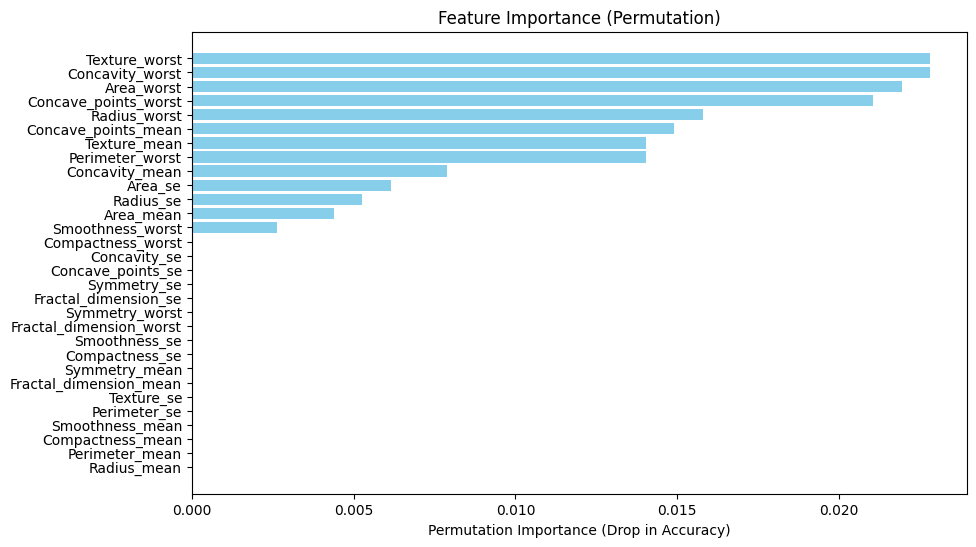

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

# 1. Recreate the Best Model
# Based on your output: max_depth=10, min_samples_split=5.
# We assume n_estimators=200 (common winner in these grids), but you can adjust.
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Fit on the training data
best_rf.fit(X_train, y_train)

# ==========================================
# A. Permutation Importance (Model Agnostic)
# ==========================================
print("Calculating Permutation Importance...")
perm_importance = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Create a DataFrame for plotting
sorted_idx = perm_importance.importances_mean.argsort()
perm_df = pd.DataFrame({
    "Feature": X_test.columns[sorted_idx],
    "Importance": perm_importance.importances_mean[sorted_idx]
})

# Plot
plt.figure(figsize=(10, 6))
plt.barh(perm_df["Feature"], perm_df["Importance"], color='skyblue')
plt.xlabel("Permutation Importance (Drop in Accuracy)")
plt.title("Feature Importance (Permutation)")
plt.show()

## **SHAP**

Detected 3D array. Selecting Class 1...


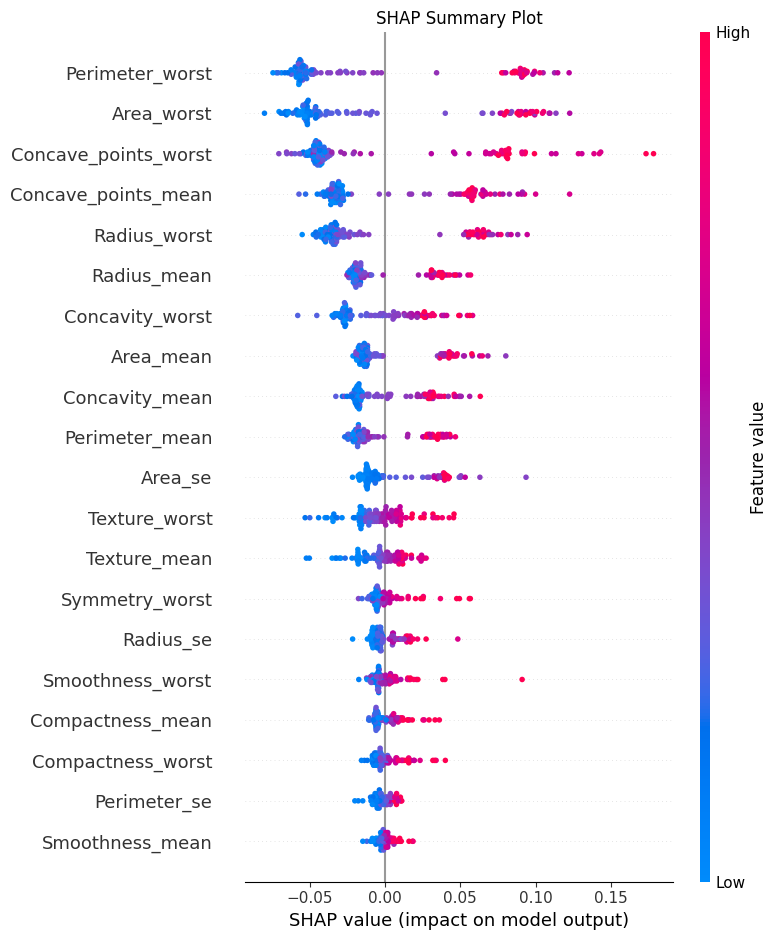

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate SHAP values
# check_additivity=False solves another common error where SHAP is too strict about precision
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test, check_additivity=False)

# 2. Automatically select the correct shape for plotting
# We check if the output is a list (Old SHAP/Some Models) or an Array (New SHAP/Binary)
if isinstance(shap_values, list):
    # It's a list of [Class 0, Class 1]. We want Class 1 (Positive)
    print("Detected list output. Selecting Class 1...")
    shap_vals_to_plot = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    # It's a 3D array (Samples, Features, Classes). Select Class 1.
    print("Detected 3D array. Selecting Class 1...")
    shap_vals_to_plot = shap_values[:, :, 1]
else:
    # It's already a 2D array for the positive class. Use as is.
    print("Detected 2D array. Using directly...")
    shap_vals_to_plot = shap_values

# 3. Plot
plt.figure()
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_vals_to_plot, X_test, plot_type="dot")

# **Section 7: Calibration Curve & Brier Scores**

## **RQ3 3.	How does model complexity (deep learning MLPs vs classical ML classifiers like SVM, Random Forest, Logistic Regression) impact predictive performance, interpretability, and potential clinical deployment in decision-support systems?**

**Calibration curves & Brier scores**

Running Calibration CV...


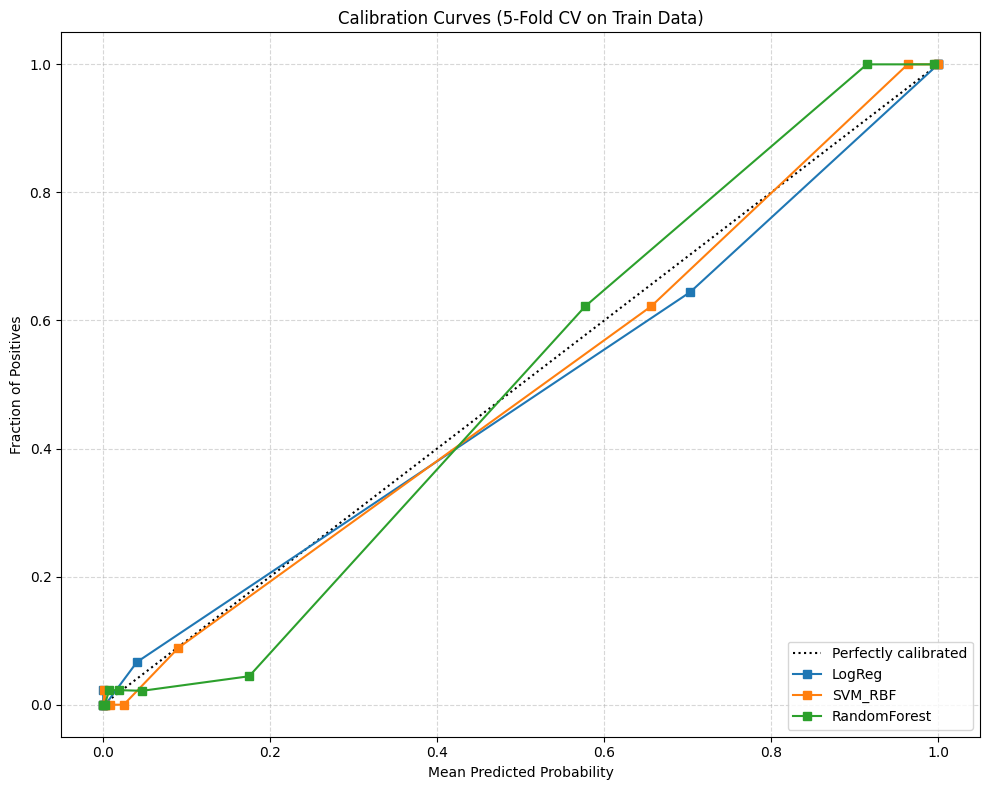


=== Calibration Metrics (Sorted by Brier Score) ===


,model,brier,roc_auc,accuracy,precision,recall,f1,specificity
1,SVM_RBF,0.021986,0.993148,0.975824,0.970414,0.964706,0.967552,0.982456
0,LogReg,0.023692,0.993375,0.967033,0.969697,0.941176,0.955224,0.982456
2,RandomForest,0.032613,0.988617,0.960440,0.952381,0.941176,0.946746,0.971930


In [ ]:
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import brier_score_loss

# 1. Setup Cross-Validation
CV_OUTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_curves = []

# Create a specific plot figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

print("Running Calibration CV...")

for name, est in best_models.items():
    try:
        # A. Generate Probabilities via Cross-Validation on TRAINING Data
        # We use X_train/y_train (not X/y)
        y_prob = cross_val_predict(
            est,
            X_train,
            y_train,
            cv=CV_OUTER,
            method="predict_proba"
        )[:, 1]

        # B. Plot Calibration Curve
        # We pass 'ax=ax' to draw all lines on the same chart
        CalibrationDisplay.from_predictions(
            y_true=y_train,
            y_prob=y_prob,
            n_bins=10,
            strategy="quantile",
            name=name,
            ax=ax
        )

        # C. Calculate Metrics Explicitly
        # Brier Score: Lower is better (0 is perfect, 0.25 is random guessing)
        brier = brier_score_loss(y_train, y_prob)

        # We assume eval_binary exists, but we add Brier manually to be safe
        row = {
            "model": name,
            "brier": brier,
            **eval_binary(y_train, y_prob, threshold=0.5)
        }
        results_curves.append(row)

    except Exception as e:
        print(f"Skipping {name}: {e}")

# Formatting the Plot
ax.set_title("Calibration Curves (5-Fold CV on Train Data)")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Display Table sorted by Brier Score (Lower is better)
print("\n=== Calibration Metrics (Sorted by Brier Score) ===")
calib_df = pd.DataFrame(results_curves).sort_values(by="brier", ascending=True)
display(calib_df)

**Threshold analysis for high-recall operating point**

Generating CV probabilities for Random Forest...
=== Threshold Analysis: Random Forest ===


,threshold,precision,recall,specificity,f1
0,0.100,0.768382,0.985849,0.823529,0.863636
1,0.125,0.785714,0.985849,0.840336,0.874477
2,0.150,0.806202,0.981132,0.859944,0.885106
3,0.175,0.818898,0.981132,0.871148,0.892704
4,0.200,0.825397,0.981132,0.876751,0.896552
5,0.225,0.848980,0.981132,0.896359,0.910284
6,0.250,0.855967,0.981132,0.901961,0.914286
7,0.275,0.877119,0.976415,0.918768,0.924107
8,0.300,0.900000,0.976415,0.935574,0.936652
9,0.325,0.911894,0.976415,0.943978,0.943052


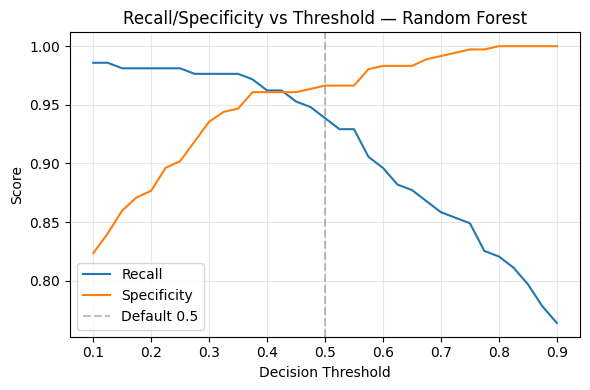

Optimal Threshold for ≥95% Recall: 0.400
Resulting Specificity: 0.961


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, confusion_matrix, precision_score, recall_score, f1_score

def threshold_table(y_true, y_prob, num=21):
    thresholds = np.linspace(0.1, 0.9, num)
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred),
            "specificity": specificity,
            "f1": f1_score(y_true, y_pred),
        })
    return pd.DataFrame(rows)

# 1. Generate probabilities for the Random Forest model
# We use cross_val_predict to simulate test-set predictions (out-of-fold)
print("Generating CV probabilities for Random Forest...")
# [:, 1] selects the probability of the positive class
y_prob_rf = cross_val_predict(rf_base, X, y, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

# 2. Create the threshold table
tab = threshold_table(y, y_prob_rf, num=33)

print("=== Threshold Analysis: Random Forest ===")
display(tab.head(10))

# 3. Plot Recall and Specificity
plt.figure(figsize=(6,4))
plt.plot(tab["threshold"], tab["recall"], label="Recall")
plt.plot(tab["threshold"], tab["specificity"], label="Specificity")
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label="Default 0.5") # Added reference line
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Recall/Specificity vs Threshold — Random Forest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Find operating threshold for High Recall (≥ 0.95)
candidates = tab[tab["recall"] >= 0.95]

if not candidates.empty:
    # Pick the threshold with the highest specificity among the high-recall candidates
    best_row = candidates.sort_values("specificity", ascending=False).iloc[0]
    t_star = best_row["threshold"]
    spec_star = best_row["specificity"]
    print(f"Optimal Threshold for ≥95% Recall: {t_star:.3f}")
    print(f"Resulting Specificity: {spec_star:.3f}")
else:
    print("No threshold reaches 0.95 recall. Inspect the table for the best trade-off.")